In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# LOAD ALL DATA
# ─────────────────────────────────────────────
routes   = pd.read_csv("Bus_Routes.csv")
stops    = pd.read_csv("Bus_Stops.csv")
mapping  = pd.read_csv("Route_Stop_Mapping.csv")
ridership = pd.read_csv("Train_Ridership_2022_to_2025H1.csv", parse_dates=["Date"])
traffic  = pd.read_csv("Train_Traffic_2022_to_2025H1.csv", parse_dates=["Date"])

In [2]:
# Derived metric — case-mandated
ridership['Total_Pax'] = ridership['Boarding_Count'] + ridership['Alighting_Count']

# Merge 1: ridership + traffic (by Date)
master = ridership.merge(traffic, on='Date', how='left')

# Merge 2: + route metadata (by Route_ID)
master = master.merge(
    routes[['Route_ID','Route_Type','Route_Length_km','Avg_Travel_Time_Min']],
    on='Route_ID', how='left')

# Merge 3: + stop metadata (by Stop_ID)
master = master.merge(
    stops[['Stop_ID','Zone','Stop_Type']], on='Stop_ID', how='left')

# Merge 4: + dwell time (by Route_ID)
dwell = mapping.groupby('Route_ID')['Dwell_Time_Min'].sum().reset_index()
dwell.columns = ['Route_ID', 'Total_Dwell_Min']
master = master.merge(dwell, on='Route_ID', how='left')

# Time features
master['Year']      = master['Date'].dt.year
master['Month']     = master['Date'].dt.month
master['DayOfWeek'] = master['Date'].dt.dayofweek   # 0=Mon, 6=Sun
master['IsWeekend'] = master['DayOfWeek'] >= 4      # Fri-Sat UAE calendar
master['Quarter']   = master['Date'].dt.quarter
master['Season']    = master['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',3:'Winter',
    4:'Spring',5:'Spring',6:'Summer',7:'Summer',
    8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'})

# Route efficiency
master['Route_Speed'] = master['Route_Length_km'] / (master['Avg_Travel_Time_Min']/60)

print(master.shape)


(195381, 22)


   Year  Total_Pax  YoY_Growth_pct
0  2022    8359137             NaN
1  2023    9127080        9.186869
2  2024   10322553       13.098088
3  2025    5642137      -45.341651
    Route_ID Route_Type  Pax_2022   Pax_2024   CAGR_pct
8        109  Intercity  490345.0   608591.0  11.406848
5        106     Feeder  638514.0   791671.0  11.349214
6        107     Feeder  737101.0   913475.0  11.322982
9        110  Intercity  578763.0   716266.0  11.246611
11       112    Express  630677.0   780343.0  11.234440
2        103       City  882471.0  1090573.0  11.167323
4        105    Express  693255.0   856643.0  11.161252
10       111       City  711404.0   878304.0  11.112848
3        104    Express  689929.0   850933.0  11.056884
1        102       City  746392.0   919649.0  11.001172
0        101       City  881201.0  1083356.0  10.878695
7        108     Feeder  679085.0   832749.0  10.737570
Year           2022     2023     2024     2025
Route_Type                                    
Cit

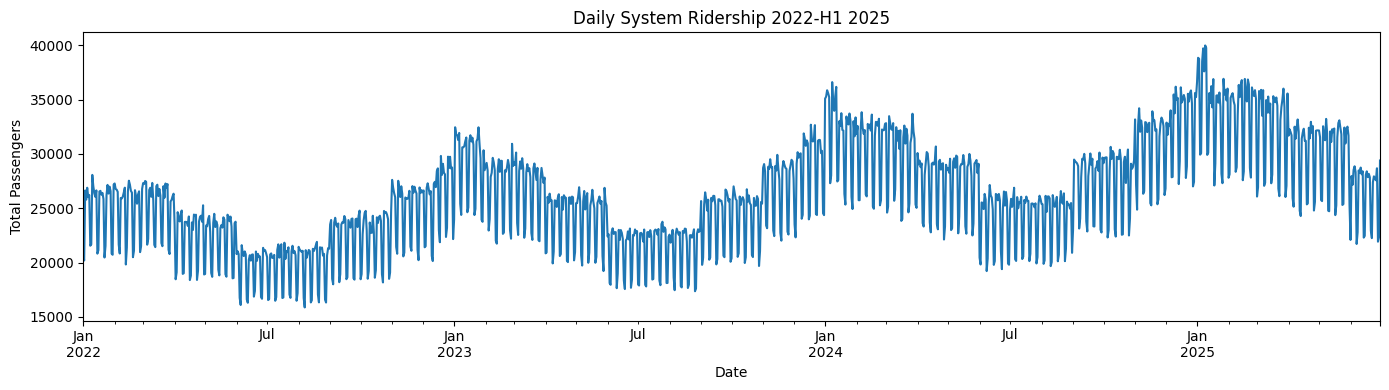

In [3]:
#Task 1 — Multi-Year Demand Dynamics (2022–H1 2025) :- Growth Decomposition
# Yearly total
yearly = master.groupby('Year')['Total_Pax'].sum().reset_index()
yearly['YoY_Growth_pct'] = yearly['Total_Pax'].pct_change() * 100
print(yearly)

# Route-level CAGR 2022 to 2024
route_year = master[master['Year'].isin([2022,2024])].groupby(
    ['Route_ID','Route_Type','Year'])['Total_Pax'].sum().reset_index()
piv = route_year.pivot_table(index=['Route_ID','Route_Type'],
    columns='Year', values='Total_Pax').reset_index()
piv.columns = ['Route_ID','Route_Type','Pax_2022','Pax_2024']
piv['CAGR_pct'] = ((piv['Pax_2024']/piv['Pax_2022'])**0.5 - 1)*100
print(piv.sort_values('CAGR_pct', ascending=False))

# Route type level
type_year = master.groupby(['Route_Type','Year'])['Total_Pax'].sum().reset_index()
type_piv = type_year.pivot(index='Route_Type',columns='Year',values='Total_Pax')
print(type_piv)

# Visual
import matplotlib.pyplot as plt
daily = master.groupby('Date')['Total_Pax'].sum()
daily.plot(figsize=(14,4), title='Daily System Ridership 2022-H1 2025')
plt.ylabel('Total Passengers'); plt.tight_layout(); plt.show()


Month
1     1.158
2     1.116
3     1.098
4     1.001
5     1.001
6     0.877
7     0.834
8     0.837
9     0.946
10    0.950
11    1.062
12    1.119
Name: Total_Pax, dtype: float64
Season
Winter    191.212980
Spring    170.481276
Autumn    167.846561
Summer    145.108313
Name: Total_Pax, dtype: float64
IsWeekend
False    182.280140
True     156.480213
Name: Total_Pax, dtype: float64
               Weekday     Weekend  Weekend_Drop_pct
Route_Type                                          
City        193.445517  170.278832        -11.975819
Express     210.164052  180.229414        -14.243463
Feeder      164.354726  138.147115        -15.945760
Intercity   150.883745  125.275700        -16.972037


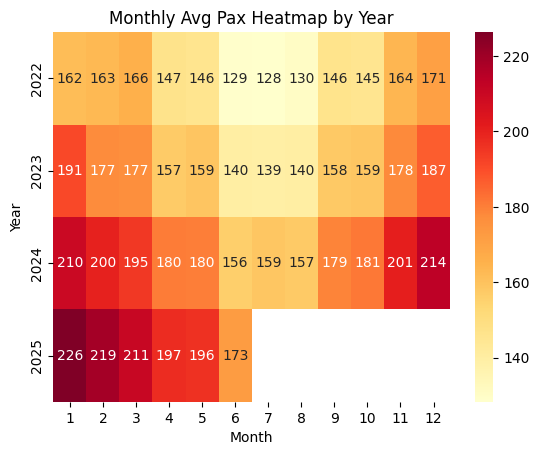

In [4]:
#Task 2 — Seasonality & Weekday/Weekend Divergence : Seasonality & Weekend Analysis
# Monthly seasonality index
monthly_avg = master.groupby('Month')['Total_Pax'].mean()
seasonal_index = monthly_avg / monthly_avg.mean()
print(seasonal_index.round(3))

# Season-level
season_avg = master.groupby('Season')['Total_Pax'].mean()
print(season_avg.sort_values(ascending=False))

# Weekday vs Weekend — system
ww = master.groupby('IsWeekend')['Total_Pax'].mean()
print(ww)   # False=Weekday 182.3, True=Weekend 156.5

# By Route Type
ww_type = master.groupby(['Route_Type','IsWeekend'])['Total_Pax'].mean().unstack()
ww_type.columns = ['Weekday','Weekend']
ww_type['Weekend_Drop_pct'] = (ww_type['Weekend']-ww_type['Weekday'])/ww_type['Weekday']*100
print(ww_type)

# Monthly heatmap
pivot = master.groupby(['Year','Month'])['Total_Pax'].mean().unstack()
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Monthly Avg Pax Heatmap by Year')
plt.show()


In [5]:
# Task 3 — Corridor-Level Structural Imbalance :- Zone total pax ranking
zone_demand = master.groupby('Zone')['Total_Pax'].sum().sort_values(ascending=False)
zone_demand_pct = zone_demand / zone_demand.sum() * 100
print(pd.concat([zone_demand, zone_demand_pct.rename('Share%')], axis=1))

# Boarding vs Alighting imbalance per zone
zone_flow = master.groupby('Zone').agg(
    Board=('Boarding_Count','sum'),
    Alight=('Alighting_Count','sum')
).reset_index()
zone_flow['Net_Flow'] = zone_flow['Board'] - zone_flow['Alight']
zone_flow['Imbalance_pct'] = zone_flow['Net_Flow'] / zone_flow['Board'] * 100
print(zone_flow.sort_values('Board', ascending=False))

# Route type efficiency: speed vs demand
route_util = master.groupby(['Route_ID','Route_Type']).agg(
    Avg_Daily_Pax=('Total_Pax','mean'),
    Avg_Speed=('Route_Speed','mean'),
    Total_Dwell=('Total_Dwell_Min','mean')
).reset_index()
print(route_util.sort_values('Avg_Daily_Pax', ascending=False))

# Stop-level hotspots
stop_demand = master.groupby('Stop_ID')['Total_Pax'].sum().nlargest(10)
stop_demand = stop_demand.reset_index().merge(
    stops[['Stop_ID','Stop_Name','Zone','Stop_Type']], on='Stop_ID')
print(stop_demand)



                       Total_Pax     Share%
Zone                                       
CBD_Downtown             8716865  26.058681
Res_AlQusais             4799695  14.348475
Core_Deira               4637778  13.864431
Res_InternationalCity    4387409  13.115964
Coastal_Marina           4328365  12.939455
CBD_BusinessBay          3368660  10.070459
Ind_JebelAli             3212135   9.602535
                    Zone    Board   Alight  Net_Flow  Imbalance_pct
1           CBD_Downtown  4474864  4242001    232863       5.203801
5           Res_AlQusais  2456020  2343675    112345       4.574271
3             Core_Deira  2377512  2260266    117246       4.931458
6  Res_InternationalCity  2251031  2136378    114653       5.093355
2         Coastal_Marina  2221259  2107106    114153       5.139113
0        CBD_BusinessBay  1727293  1641367     85926       4.974605
4           Ind_JebelAli  1646233  1565902     80331       4.879686
    Route_ID Route_Type  Avg_Daily_Pax  Avg_Speed  Total_Dwe

   Congestion_Level     Avg_Pax  Days
0                 1  160.365579   256
1                 2  166.876170   426
2                 3  177.251237   296
3                 4  172.766992   183
4                 5  193.170836   116
                  Total_Pax  Congestion_Level  Avg_Speed_kmph
Total_Pax          1.000000          0.137516       -0.110317
Congestion_Level   0.137516          1.000000       -0.938956
Avg_Speed_kmph    -0.110317         -0.938956        1.000000
City: elasticity corr = 0.1385
Express: elasticity corr = 0.1476
Feeder: elasticity corr = 0.1540
Intercity: elasticity corr = 0.1584
Congestion trend by year:
Year
2022    2.490411
2023    2.553425
2024    2.631148
2025    2.784530
Name: Congestion_Level, dtype: float64


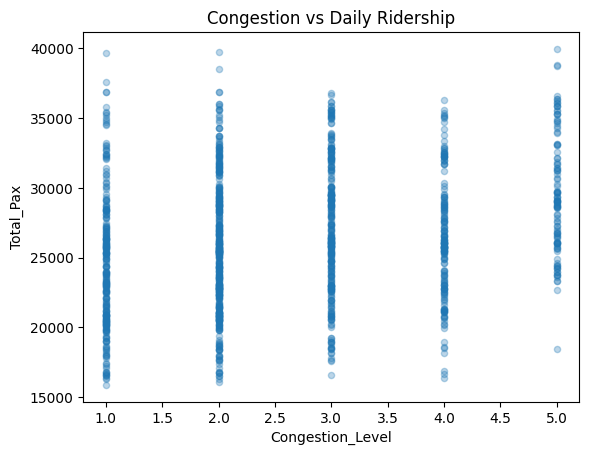

In [6]:
# Task 4 — Congestion-Demand Interaction :- Congestion level vs avg pax
# Congestion Elasticity
cong_demand = master.groupby('Congestion_Level').agg(
    Avg_Pax=('Total_Pax','mean'),
    Days=('Date','nunique')
).reset_index()
print(cong_demand)

# Correlation matrix
corr = master[['Total_Pax','Congestion_Level','Avg_Speed_kmph']].corr()
print(corr)

# Elasticity by Route Type
for rt in master['Route_Type'].unique():
    sub = master[master['Route_Type']==rt]
    corr = sub['Total_Pax'].corr(sub['Congestion_Level'])
    print(f'{rt}: elasticity corr = {corr:.4f}')

# Congestion trend over time (worsening?)
monthly_cong = traffic.copy()
monthly_cong['Year'] = monthly_cong['Date'].dt.year
monthly_cong['Month'] = monthly_cong['Date'].dt.month
cong_trend = monthly_cong.groupby(['Year'])['Congestion_Level'].mean()
print('Congestion trend by year:')
print(cong_trend)   # Shows gradual worsening

# Visual: congestion vs pax scatter
daily_pax = master.groupby('Date')['Total_Pax'].sum().reset_index()
daily_merged = daily_pax.merge(traffic, on='Date')
daily_merged.plot.scatter(x='Congestion_Level', y='Total_Pax',
    alpha=0.3, title='Congestion vs Daily Ridership')
plt.show()


In [7]:
# Task 5 — H2 2025 Demand Forecast (July-December):- Forecasting
# Step 1: H2 historical by route
h2_hist = master[master['Month'].between(7,12)].groupby(
    ['Route_ID','Route_Type','Year'])['Total_Pax'].sum().reset_index()
h2_piv = h2_hist.pivot_table(index=['Route_ID','Route_Type'],
    columns='Year', values='Total_Pax').reset_index()

# Step 2: Growth rate from 2023 to 2024
h2_piv['Growth_23_24'] = h2_piv[2024] / h2_piv[2023] - 1
h2_piv['Forecast_H2_2025'] = h2_piv[2024] * (1 + h2_piv['Growth_23_24'])

# Step 3: Monthly decomposition using seasonal index
seasonal_idx = {7: 0.834, 8: 0.837, 9: 0.946, 10: 0.950, 11: 1.062, 12: 1.119}
h2_months = [7,8,9,10,11,12]

forecast_rows = []
for _, row in h2_piv.iterrows():
    annual_rate = row['Forecast_H2_2025'] / sum(seasonal_idx[m] for m in h2_months)
    for m in h2_months:
        forecast_rows.append({
            'Route_ID': row['Route_ID'],
            'Route_Type': row['Route_Type'],
            'Month': m,
            'Forecast_Pax': annual_rate * seasonal_idx[m]
        })

forecast_df = pd.DataFrame(forecast_rows)
print(forecast_df.pivot_table(
    index='Route_ID', columns='Month', values='Forecast_Pax', aggfunc='sum'))


Month               7             8              9              10  \
Route_ID                                                             
101       88832.107005  89151.646958  100761.598593  101187.651864   
102       74023.793735  74290.066374   83964.638936   84319.669122   
103       89843.694455  90166.873213  101909.034718  102339.939727   
104       69552.535193  69802.724169   78892.923613   79226.508913   
105       69132.894064  69381.573539   78416.927799   78748.500432   
106       64130.987596  64361.674601   72743.302477   73050.885151   
107       75951.155677  76224.361273   86150.831260   86515.105387   
108       67667.918289  67911.328067   76755.216668   77079.763039   
109       49775.074173  49954.121203   56459.496604   56698.225977   
110       58294.610224  58504.303067   66123.143012   66402.733469   
111       72072.576922  72331.830795   81751.388211   82097.060043   
112       63806.244043  64035.762906   72374.948279   72680.973430   

Month              

In [8]:
# Task 6 :- Operational Recommendations - Fleet Reallocation Strategy
# Compute fleet allocation score: demand per km of route
route_summary = master.groupby(['Route_ID','Route_Type']).agg(
    Avg_Daily_Pax=('Total_Pax','mean'),
    Route_km=('Route_Length_km','mean'),
    Dwell_Min=('Total_Dwell_Min','mean')
).reset_index()
route_summary['Pax_per_km'] = route_summary['Avg_Daily_Pax'] / route_summary['Route_km']
route_summary['Efficiency_Score'] = route_summary['Avg_Daily_Pax'] / route_summary['Dwell_Min']
print(route_summary.sort_values('Pax_per_km', ascending=False))



    Route_ID Route_Type  Avg_Daily_Pax  Route_km  Dwell_Min  Pax_per_km  \
4        105    Express     197.563537     12.48      10.92   15.830412   
2        103       City     184.281859     14.57      20.69   12.648034   
7        108     Feeder     151.614722     13.89      17.01   10.915387   
9        110  Intercity     139.965845     13.01      15.25   10.758328   
11       112    Express     197.421926     19.02      12.36   10.379702   
1        102       City     179.928679     18.09      15.65    9.946306   
0        101       City     184.143670     20.74      18.68    8.878673   
3        104    Express     196.978501     23.18      14.07    8.497778   
6        107     Feeder     153.744714     18.10      20.30    8.494183   
8        109  Intercity     139.810280     22.08      15.87    6.331987   
5        106     Feeder     153.982230     27.03      15.22    5.696716   
10       111       City     185.605260     34.40      15.63    5.395502   

    Efficiency_Score  
4